In [1]:
import gymnasium as gym
import ale_py

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyvirtualdisplay import Display

%matplotlib inline

In [2]:
env_name = "ALE/MsPacman-v5"

env = gym.make(env_name, render_mode="rgb_array")

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


### Exploring the environment

In [3]:
env.action_space

Discrete(9)

In [4]:
list(range(env.action_space.n))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [5]:
for i in range(10):
    print(str(i) + ": ", env.action_space.sample())

0:  3
1:  6
2:  8
3:  0
4:  5
5:  6
6:  6
7:  4
8:  0
9:  6


Action space is a (9,) vector then. With discrete actions being lit up.

In [6]:
env.observation_space

Box(0, 255, (210, 160, 3), uint8)

So the observation space is 210x160 3-channel array with values between 0-255 in RGB array mode

In [7]:
obs, info = env.reset()

In [8]:
info

{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

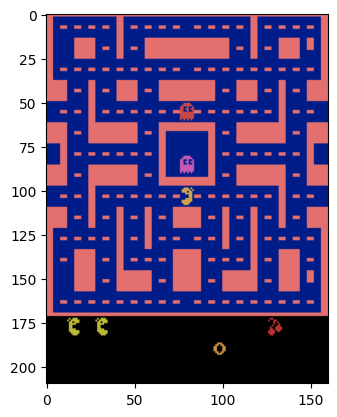

In [9]:
plt.imshow(obs)

### Reshaping the observation

3 0.0 False False {'lives': 3, 'episode_frame_number': 4, 'frame_number': 4}
(65, 84)


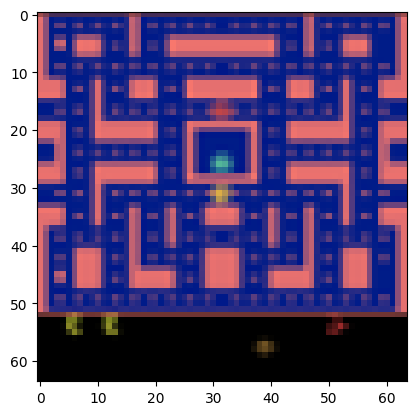

In [10]:
from PIL import Image
env_64 = gym.wrappers.ResizeObservation(env, (84, 65))

# obs, info  = env_64.reset()

sample_act = env.action_space.sample()
obs, reward, truncated, terminated, info = env_64.step(sample_act)
print(sample_act, reward, truncated, terminated, info)

obs = Image.fromarray(obs)
plt.imshow(obs.resize((64, 64)))        # Resizing keeping the frame aspect ratio

print(obs.size)

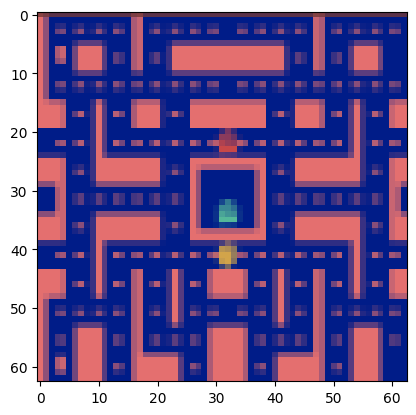

In [11]:
# Cropping the observation
obs = obs.crop((0, 0, 63, 63))
plt.imshow(obs)

### Recording and Evaluating rollouts

In [12]:
num_eval_eps = 5

env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(
    env_rec, buffer_length=num_eval_eps
)

rewards_hist = []

/home/utkarsh/active_projects/world-models/.venv/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/utkarsh/active_projects/world-models/videos/examples folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [13]:
for ep_num in range(num_eval_eps):
    obs, info = env_rec.reset()
    ep_reward = 0
    step_count = 0
    
    while True:
        action = env_rec.action_space.sample()
        obs, reward, terminated, truncated, info= env_rec.step(action)
        
        ep_reward += float(reward)
        step_count += 1
        
        if (terminated or truncated): break
    
    print(f"Episode {ep_num + 1}: {step_count} steps, reward = {ep_reward}")

env_rec.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(env_rec.time_queue)}')
print(f'Episode rewards: {list(env_rec.return_queue)}')
print(f'Episode lengths: {list(env_rec.length_queue)}')

# Calculate some useful metrics
avg_reward = np.mean(env_rec.return_queue)
avg_length = np.sum(env_rec.length_queue)
std_reward = np.std(env_rec.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} ± {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in env_rec.return_queue if r > 0) / len(env_rec.return_queue):.1%}')


Episode 1: 525 steps, reward = 210.0
Episode 2: 579 steps, reward = 320.0
Episode 3: 599 steps, reward = 290.0
Episode 4: 521 steps, reward = 280.0
Episode 5: 405 steps, reward = 160.0

Evaluation Summary:
Episode durations: [0.606527, 0.689524, 0.542753, 0.814158, 0.558266]
Episode rewards: [210.0, 320.0, 290.0, 280.0, 160.0]
Episode lengths: [525, 579, 599, 521, 405]

Average reward: 252.00 ± 58.45
Average episode length: 2629.0 steps
Success rate: 100.0%


### Checking `env.reset()` multiple times

In [14]:
env = gym.make(env_name, render_mode="rgb_array")

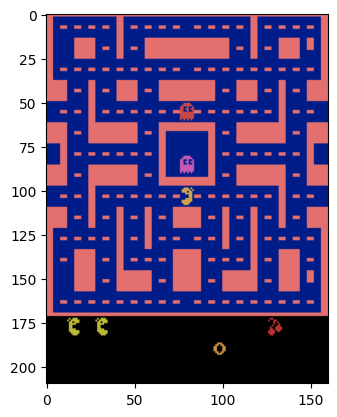

In [15]:
obs, info = env.reset()
plt.imshow(obs)

## Checking the NoOp on Reset

Whenever I'm visualizing MsPacman, it seems that for the couple of frames, even though there's a control signal being sent, there are no changes in the actual environment. I need to probe it first.

In [16]:
env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video-trial"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(env_rec)

rewards_hist = []

In [17]:
obs, info = env_rec.reset()
prev_obs = obs.copy()

frame_idx = 0
for frame_idx in range(65):
    action = env_rec.action_space.sample()
    obs, reward, terminated, truncated, info = env_rec.step(action)
    # diff = np.abs(obs.astype(int) - prev_obs.astype(int)).sum()
    # print(frame_idx, diff, action, info.get("lives"))
    print(frame_idx, action, info.get("lives"))
    prev_obs = obs.copy()
    
    if (terminated or truncated): break

env_rec.close()

0 6 3
1 6 3
2 3 3
3 6 3
4 7 3
5 6 3
6 0 3
7 6 3
8 5 3
9 7 3
10 1 3
11 7 3
12 0 3
13 7 3
14 3 3
15 8 3
16 2 3
17 6 3
18 4 3
19 2 3
20 3 3
21 5 3
22 7 3
23 5 3
24 5 3
25 8 3
26 3 3
27 8 3
28 8 3
29 6 3
30 8 3
31 8 3
32 4 3
33 7 3
34 1 3
35 3 3
36 4 3
37 4 3
38 1 3
39 8 3
40 6 3
41 4 3
42 3 3
43 7 3
44 7 3
45 4 3
46 8 3
47 4 3
48 3 3
49 0 3
50 5 3
51 7 3
52 4 3
53 1 3
54 8 3
55 4 3
56 3 3
57 8 3
58 0 3
59 1 3
60 6 3
61 2 3
62 4 3
63 1 3
64 7 3


## Comparing different interpolation strategies for resizing according to the preprocessing pipeline

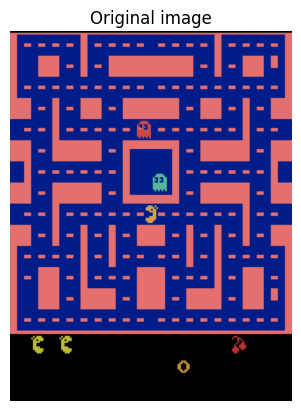

In [20]:
frame, _, _, _, _ = env.step(env.action_space.sample())

plt.imshow(frame)
plt.title("Original image")
plt.axis("off")
plt.show()

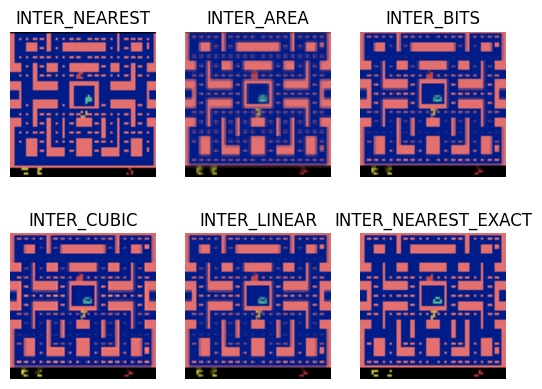

In [25]:
import cv2

# Preprocessing pipeline for the frame
frame = frame[:186, :160, :]

# Comparing different interpolation strats
strats = [cv2.INTER_NEAREST, cv2.INTER_AREA, cv2.INTER_BITS, cv2.INTER_CUBIC, cv2.INTER_LINEAR, cv2.INTER_NEAREST_EXACT]
names = ["INTER_NEAREST", "INTER_AREA", "INTER_BITS", "INTER_CUBIC", "INTER_LINEAR", "INTER_NEAREST_EXACT"]

fig, axs = plt.subplots(2, 3)

for ax, strat, name in zip(axs.flat, strats, names):
    ax.imshow(cv2.resize(frame, (64, 64), interpolation=strat))
    ax.set_title(str(name))
    ax.axis("off")
    
plt.show()